In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import Python libraries and KIND framework files --!

import torch
import numpy as np
from   matplotlib import pyplot as plt

import kind
import utils_data

In [2]:
# --! specify kind arguments --!

parser = kind.create_args_parser()

args = parser.parse_args(
    args=[
        '--data_name', 'SRF gun simulation',
        '--data_dir', '../../data/delay',
        '--data_file', 'gun_sim',
        '--data_nsample', '200',
        '--data_scale_min', '-1',
        '--data_scale_max', '1',
        '--data_train_size', '0.6',
        '--data_test_size', '0.5',

        '--feature_dim', '0,1',
        '--target_dim', '0',
        '--lookback_nsample', '48',
        '--forecast_nsample', '48',

        '--batch_size', '64',
        '--learning_rate', '0.001',
        '--weight_decay', '0.0001',
        '--nepoch', '50',
        '--patience', '10',
        '--checkpoints', '../../models/delay',

        '--seg_nsample_stat', '24',
        '--seg_nsample_trans', '24',
        '--fun_stat', '{"sin": 5, "cos": 5}',
        '--fun_trans', '{"data": 10}',
    ]
)

In [3]:
dataset = utils_data.dataset_factory().create_dataset(args)

In [4]:
model = kind.model(args)

In [5]:
model.fit(dataset)

>>> train stationary mean >>>
	epoch 1 losses: train=0.211607, valid=0.027916, test=0.027542
	validation loss decreased (inf -> 0.027916), saving model ...
	epoch 2 losses: train=0.015913, valid=0.016960, test=0.016494
	validation loss decreased (0.027916 -> 0.016960), saving model ...
	epoch 3 losses: train=0.011285, valid=0.015656, test=0.015371
	validation loss decreased (0.016960 -> 0.015656), saving model ...
	epoch 4 losses: train=0.010116, valid=0.015200, test=0.014849
	validation loss decreased (0.015656 -> 0.015200), saving model ...
	epoch 5 losses: train=0.009162, valid=0.014385, test=0.013729
	validation loss decreased (0.015200 -> 0.014385), saving model ...
	epoch 6 losses: train=0.008600, valid=0.013866, test=0.013551
	validation loss decreased (0.014385 -> 0.013866), saving model ...
	epoch 7 losses: train=0.007857, valid=0.013578, test=0.013061
	validation loss decreased (0.013866 -> 0.013578), saving model ...
	epoch 8 losses: train=0.007476, valid=0.012885, test=0.01

In [6]:
model.eval()
_, _, data_loader = dataset.load(data_type='stat')

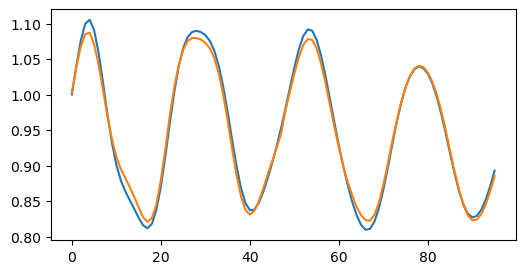

In [19]:
jdata = 0

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        stat = model_output[1]

        plt.figure(figsize=(6,3))
        plt.plot(truth[jdata, :, :1])
        plt.plot(stat[0, :, :1])
        plt.show()

        break

In [20]:
model.train()
model.fit_next()
model.fit(dataset)

>>> train stationary uncertainty >>>
	epoch 1 losses: train=-0.516012, valid=-0.446579, test=-0.436144
	validation loss decreased (inf -> -0.446579), saving model ...
	epoch 2 losses: train=-0.823013, valid=-0.457771, test=-0.454971
	validation loss decreased (-0.446579 -> -0.457771), saving model ...
	epoch 3 losses: train=-0.914585, valid=-0.538846, test=-0.535940
	validation loss decreased (-0.457771 -> -0.538846), saving model ...
	epoch 4 losses: train=-0.957573, valid=-0.579935, test=-0.586845
	validation loss decreased (-0.538846 -> -0.579935), saving model ...
	epoch 5 losses: train=-0.986862, valid=-0.569328, test=-0.570410
	early stopping counter: 1 out of 10
	epoch 6 losses: train=-1.003033, valid=-0.611359, test=-0.611545
	validation loss decreased (-0.579935 -> -0.611359), saving model ...
	epoch 7 losses: train=-1.022862, valid=-0.623277, test=-0.626746
	validation loss decreased (-0.611359 -> -0.623277), saving model ...
	epoch 8 losses: train=-1.037697, valid=-0.642452,

In [21]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

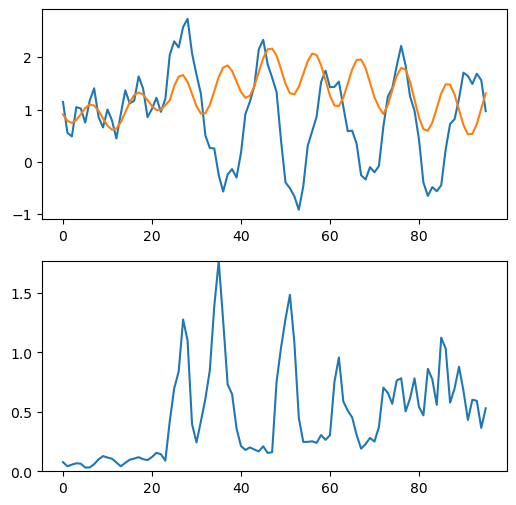

In [22]:
jdata = 1

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        stat = model_output[1]
        stat_uncertain = model_output[2]
        stat_uncertain = torch.exp(stat_uncertain) + 1e-6
        stat_uncertain_max = torch.max(stat_uncertain)
        stat_uncertain_max = 0.1 if stat_uncertain_max < 0.1 else stat_uncertain_max

        plt.figure(figsize=(6,6))

        plt.subplot(2,1,1)
        plt.plot(truth[jdata, :, :1])
        plt.plot(stat[0, :, :1])

        plt.subplot(2,1,2)
        plt.plot(stat_uncertain[0, :, :1])
        plt.ylim((0., stat_uncertain_max))

        plt.show()

        break

In [23]:
model.train()
model.fit_next()
model.fit(dataset)

>>> train transient mean >>>
	epoch 1 losses: train=0.161194, valid=0.114807, test=0.113964
	validation loss decreased (inf -> 0.114807), saving model ...
	epoch 2 losses: train=0.062673, valid=0.087782, test=0.086915
	validation loss decreased (0.114807 -> 0.087782), saving model ...
	epoch 3 losses: train=0.047030, valid=0.085094, test=0.084381
	validation loss decreased (0.087782 -> 0.085094), saving model ...
	epoch 4 losses: train=0.041171, valid=0.084972, test=0.084240
	validation loss decreased (0.085094 -> 0.084972), saving model ...
	epoch 5 losses: train=0.030559, valid=0.079152, test=0.078796
	validation loss decreased (0.084972 -> 0.079152), saving model ...
	epoch 6 losses: train=0.024479, valid=0.077881, test=0.077457
	validation loss decreased (0.079152 -> 0.077881), saving model ...
	epoch 7 losses: train=0.016108, valid=0.071113, test=0.071071
	validation loss decreased (0.077881 -> 0.071113), saving model ...
	epoch 8 losses: train=0.012229, valid=0.070300, test=0.070

In [24]:
model.eval()
_, _, data_loader = dataset.load(data_type='trans')

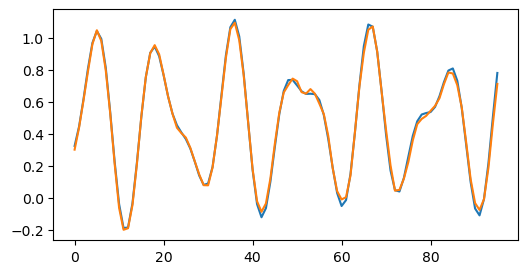

In [25]:
jdata = 0

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        trans = model_output[3]

        plt.figure(figsize=(6,3))
        plt.plot(truth[jdata, :, :1])
        plt.plot(trans[0, :, :1])

        plt.show()

        break

In [26]:
model.train()
model.fit_next()
model.fit(dataset)

>>> train transient uncertainty >>>
	epoch 1 losses: train=-1.077509, valid=-0.625017, test=-0.627094
	validation loss decreased (inf -> -0.625017), saving model ...
	epoch 2 losses: train=-1.466725, valid=-0.704781, test=-0.707483
	validation loss decreased (-0.625017 -> -0.704781), saving model ...
	epoch 3 losses: train=-1.492573, valid=-0.628214, test=-0.630340
	early stopping counter: 1 out of 10
	epoch 4 losses: train=-1.504385, valid=-0.637675, test=-0.639243
	early stopping counter: 2 out of 10
	epoch 5 losses: train=-1.510940, valid=-0.680703, test=-0.681839
	early stopping counter: 3 out of 10
	epoch 6 losses: train=-1.517047, valid=-0.673913, test=-0.676708
	early stopping counter: 4 out of 10
	epoch 7 losses: train=-1.523321, valid=-0.715180, test=-0.719330
	validation loss decreased (-0.704781 -> -0.715180), saving model ...
	epoch 8 losses: train=-1.525497, valid=-0.786165, test=-0.784859
	validation loss decreased (-0.715180 -> -0.786165), saving model ...
	epoch 9 losse

In [27]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

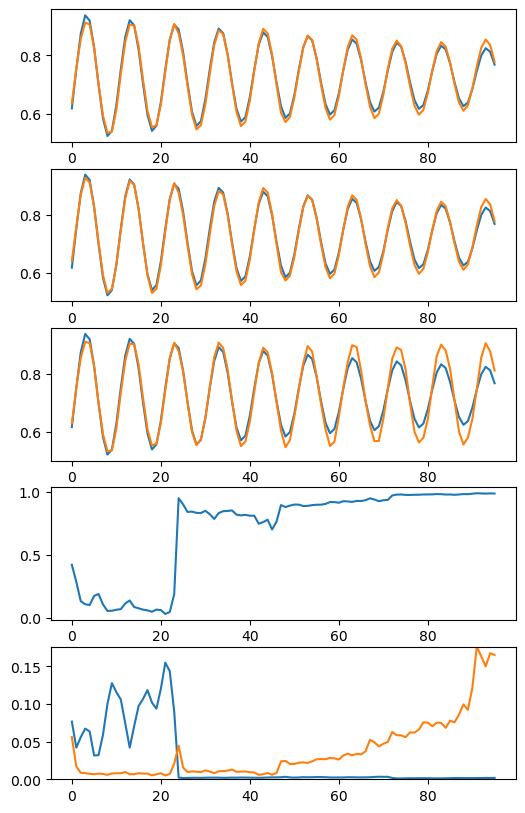

In [28]:
jdata = 0

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        blend = model_output[0]
        stat = model_output[1]
        trans = model_output[3]
        alpha = model_output[9]

        stat_uncertain = model_output[2]
        stat_uncertain = torch.exp(stat_uncertain) + 1e-6
        stat_uncertain_max = torch.max(stat_uncertain)
        stat_uncertain_max = 0.1 if stat_uncertain_max < 0.1 else stat_uncertain_max

        trans_uncertain = model_output[4]
        trans_uncertain = torch.exp(trans_uncertain) + 1e-6
        trans_uncertain_max = torch.max(trans_uncertain)
        trans_uncertain_max = 0.1 if trans_uncertain_max < 0.1 else trans_uncertain_max

        uncertain_max = stat_uncertain_max if stat_uncertain_max > trans_uncertain_max else trans_uncertain_max
        uncertain_max = 0.1 if uncertain_max < 0.1 else uncertain_max

        plt.figure(figsize=(6,10))

        plt.subplot(5,1,1)
        plt.plot(truth[jdata, :, :1])
        plt.plot(blend[0, :, :1])

        plt.subplot(5,1,2)
        plt.plot(truth[jdata, :, :1])
        plt.plot(stat[0, :, :1])

        plt.subplot(5,1,3)
        plt.plot(truth[jdata, :, :1])
        plt.plot(trans[0, :, :1])

        plt.subplot(5,1,4)
        plt.plot(alpha[0, :, :1])

        plt.subplot(5,1,5)
        plt.plot(stat_uncertain[0,:,:1])
        plt.plot(trans_uncertain[0,:,:1])
        plt.ylim((0., uncertain_max))

        plt.show()

        break